In [2]:
import xarray as xr
import rioxarray
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from scipy.ndimage import median_filter, minimum_filter, maximum_filter, uniform_filter
import lightgbm as lgb 
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [3]:
vrt_dir = Path("../data/bronze/ghana-2022-jan/vrt_files")

# Bands to load
band_to_name = {
    "B02": "blue",
    "B03": "green",
    "B04": "red",
    "B05": "rededge",
    "B06": "B06",
    "B07": "B07",
    "B08": "nir",
    "B8A": "B8A",
    "B11": "swir11",
    "B12": "swir22",
}

# Load each band and assign a name
bands = {}
for band, name in band_to_name.items():
    da = rioxarray.open_rasterio(vrt_dir / f"{band}.vrt", masked=False, chunks=True)
    da = da.squeeze("band", drop=True)
    bands[name] = da

# Combine into a Dataset — all bands aligned on (y, x)
ds = xr.Dataset(bands)

aux_names = ["cloud_confidence", "scene_classification", "valid_observations"]
for aux in aux_names:
    da = rioxarray.open_rasterio(vrt_dir / f"{aux}.vrt", masked=False, chunks=True)
    ds[aux] = da.squeeze("band", drop=True)

print(ds)

<xarray.Dataset> Size: 48GB
Dimensions:               (x: 50398, y: 73757)
Coordinates:
  * x                     (x) float64 403kB -3.261 -3.261 -3.261 ... 1.273 1.273
  * y                     (y) float64 590kB 11.17 11.17 11.17 ... 4.539 4.539
    spatial_ref           int64 8B 0
Data variables: (12/13)
    blue                  (y, x) uint8 4GB dask.array<chunksize=(11520, 11520), meta=np.ndarray>
    green                 (y, x) uint8 4GB dask.array<chunksize=(11520, 11520), meta=np.ndarray>
    red                   (y, x) uint8 4GB dask.array<chunksize=(11520, 11520), meta=np.ndarray>
    rededge               (y, x) uint8 4GB dask.array<chunksize=(11520, 11520), meta=np.ndarray>
    B06                   (y, x) uint8 4GB dask.array<chunksize=(11520, 11520), meta=np.ndarray>
    B07                   (y, x) uint8 4GB dask.array<chunksize=(11520, 11520), meta=np.ndarray>
    ...                    ...
    B8A                   (y, x) uint8 4GB dask.array<chunksize=(11520, 11520),

EPSG:4326


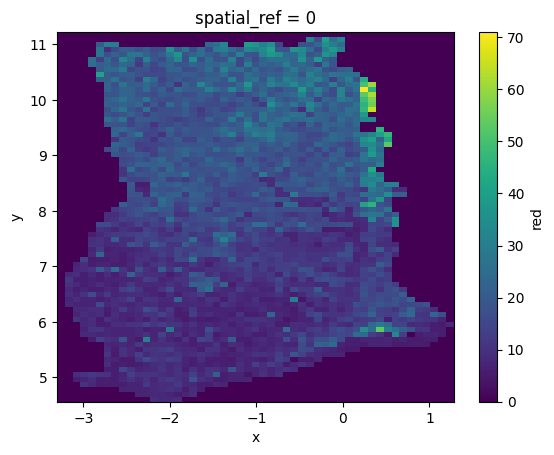

In [5]:
# Check CRS and resolution
print(ds.rio.crs)

# Downsample & plot
step = 1000
ds_small = ds.isel(y=slice(None, None, step), x=slice(None, None, step))
ds_small.red.plot()

In [6]:
# Open the ETHZ data and clip to the bounding box
ethz_ds = rioxarray.open_rasterio("../data/bronze/cocoa_map.tif", masked=True, chunks=True)
print(ethz_ds.rio.crs)
bounds = ds.rio.bounds()  # (left, bottom, right, top)
clipped_ethz_ds = ethz_ds.rio.clip_box(*bounds)

# Convert to uint16 to lower data footprint
UINT16_NODATA = 65535
clipped_ethz_ds = (clipped_ethz_ds * 1000).fillna(UINT16_NODATA).round().astype(np.uint16)
clipped_ethz_ds.rio.write_nodata(UINT16_NODATA, inplace=True)
clipped_ethz_ds.attrs["scale_factor"] = 0.001
clipped_ethz_ds.attrs["add_offset"] = 0.0

print(clipped_ethz_ds)

EPSG:4326
<xarray.DataArray (band: 1, y: 73264, x: 49173)> Size: 7GB
dask.array<astype, shape=(1, 73264, 49173), dtype=uint16, chunksize=(1, 310, 49173), chunktype=numpy.ndarray>
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 586kB 11.17 11.17 11.17 11.17 ... 4.539 4.539 4.539
  * x            (x) float64 393kB -3.261 -3.261 -3.261 ... 1.191 1.192 1.192
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   0.001
    add_offset:     0.0
    _FillValue:     65535


In [7]:
clipped_ethz_reprojected_ds = clipped_ethz_ds.rio.reproject_match(ds)
ds["ethz_map"] = clipped_ethz_reprojected_ds.squeeze("band", drop=True)
print(ds)

<xarray.Dataset> Size: 56GB
Dimensions:               (x: 50398, y: 73757)
Coordinates:
  * x                     (x) float64 403kB -3.261 -3.261 -3.261 ... 1.273 1.273
  * y                     (y) float64 590kB 11.17 11.17 11.17 ... 4.539 4.539
    spatial_ref           int64 8B 0
Data variables: (12/14)
    blue                  (y, x) uint8 4GB dask.array<chunksize=(11520, 11520), meta=np.ndarray>
    green                 (y, x) uint8 4GB dask.array<chunksize=(11520, 11520), meta=np.ndarray>
    red                   (y, x) uint8 4GB dask.array<chunksize=(11520, 11520), meta=np.ndarray>
    rededge               (y, x) uint8 4GB dask.array<chunksize=(11520, 11520), meta=np.ndarray>
    B06                   (y, x) uint8 4GB dask.array<chunksize=(11520, 11520), meta=np.ndarray>
    B07                   (y, x) uint8 4GB dask.array<chunksize=(11520, 11520), meta=np.ndarray>
    ...                    ...
    swir11                (y, x) uint8 4GB dask.array<chunksize=(11520, 11520),

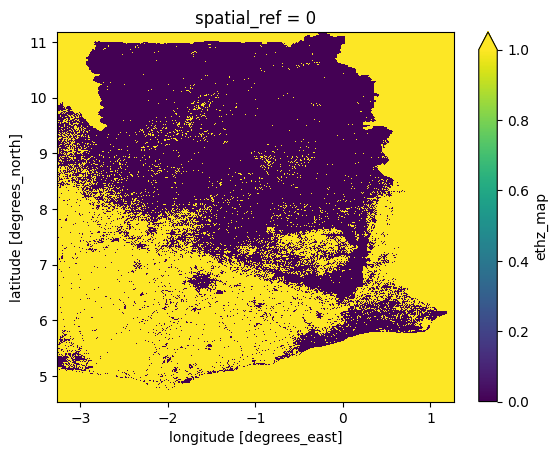

In [8]:
# Downsample and plot
step = 100
ds_small = ds.isel(y=slice(None, None, step), x=slice(None, None, step))
ds_small.ethz_map.plot(vmin=0, vmax=1)

In [9]:
# Ensure all layers have same chunks
ds = ds.chunk(chunks={'x': 1000, 'y': 1000})

In [10]:
ds.to_zarr('../data/silver/ghana-2022.zarr', mode="w", consolidated=True)

/home/aga/Documents/clients/forestero/skymap/skymap/.venv/lib/python3.14/site-packages/zarr/api/asynchronous.py:231: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
